# Diversity by County

# Clean data
Merge the column with the data dictionary + merge multiracial categories. 

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
racial_census_df = pd.read_csv('../data/racialcensusdata.csv')

In [5]:
racial_census_df.head(5)

,GEO_ID,NAME,P9_001N,P9_002N,P9_003N,P9_004N,P9_005N,P9_006N,P9_007N,P9_008N,...,P9_065N,P9_066N,P9_067N,P9_068N,P9_069N,P9_070N,P9_071N,P9_072N,P9_073N,Unnamed: 75
0,Geography,Geographic Area Name,!!Total:,!!Total:!!Hispanic or Latino,!!Total:!!Not Hispanic or Latino:,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,NaN
1,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,...,0,0,0,0,0,0,0,0,0,NaN
2,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,...,0,0,0,0,0,0,0,0,0,NaN
3,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,...,2,2,0,0,0,0,0,0,0,NaN
4,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,...,0,0,0,0,0,0,0,0,0,NaN


In [6]:
df_subset = racial_census_df.iloc[:, :13].copy()

In [7]:
df_subset

,GEO_ID,NAME,P9_001N,P9_002N,P9_003N,P9_004N,P9_005N,P9_006N,P9_007N,P9_008N,P9_009N,P9_010N,P9_011N
0,Geography,Geographic Area Name,!!Total:,!!Total:!!Hispanic or Latino,!!Total:!!Not Hispanic or Latino:,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...,!!Total:!!Not Hispanic or Latino:!!Population...
1,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,22,185,2490
2,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,122,775,10368
3,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,0,63,553
4,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,9,47,600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,0500000US72145,"Vega Baja Municipio, Puerto Rico",54414,54012,402,353,279,31,9,11,0,23,49
3218,0500000US72147,"Vieques Municipio, Puerto Rico",8249,7586,663,653,533,47,15,3,0,55,10
3219,0500000US72149,"Villalba Municipio, Puerto Rico",22093,22008,85,80,65,3,5,1,0,6,5
3220,0500000US72151,"Yabucoa Municipio, Puerto Rico",30426,30258,168,156,115,12,1,8,2,18,12


In [8]:
# Create a dictionary mapping the current index to a clean name
new_names = {
    df_subset.columns[0]: 'GEO_ID',
    df_subset.columns[1]: 'County_Name',
    df_subset.columns[2]: 'Total_Pop',
    df_subset.columns[3]: 'Hispanic_Latino',
    df_subset.columns[4]: 'Not_Hispanic_Total',
    df_subset.columns[5]: 'One_Race_Total',
    df_subset.columns[6]: 'White_alone',
    df_subset.columns[7]: 'Black_alone',
    df_subset.columns[8]: 'AIAN_alone',   # American Indian / Alaska Native
    df_subset.columns[9]: 'Asian_alone',
    df_subset.columns[10]: 'NHPI_alone',  # Native Hawaiian / Pacific Islander
    df_subset.columns[11]: 'Other_alone',
    df_subset.columns[12]: 'Two_or_More'  # This is the multiracial category
}

# Apply the rename
df_subset = df_subset.drop(0).reset_index(drop=True)
df_subset = df_subset.rename(columns=new_names)


# Make sure the numbers are actually numbers (int) for analysis
cols_to_fix = df_subset.columns[2:]
df_subset[cols_to_fix] = df_subset[cols_to_fix].apply(pd.to_numeric)

df_subset.head()

,GEO_ID,County_Name,Total_Pop,Hispanic_Latino,Not_Hispanic_Total,One_Race_Total,White_alone,Black_alone,AIAN_alone,Asian_alone,NHPI_alone,Other_alone,Two_or_More
0,0500000US01001,"Autauga County, Alabama",58805,2117,56688,54198,41582,11352,184,873,22,185,2490
1,0500000US01003,"Baldwin County, Alabama",231767,12686,219081,208713,186495,18001,1291,2029,122,775,10368
2,0500000US01005,"Barbour County, Alabama",25223,1510,23713,23160,11086,11850,58,103,0,63,553
3,0500000US01007,"Bibb County, Alabama",22293,740,21553,20953,16442,4390,39,26,9,47,600
4,0500000US01009,"Blount County, Alabama",59134,5771,53363,51063,49764,826,188,174,11,100,2300


In [9]:
# 1. Define the columns that make up the 100% total population
race_columns = ['Hispanic_Latino', 'White_alone', 'Black_alone', 'AIAN_alone', 
                'Asian_alone', 'NHPI_alone', 'Other_alone', 'Two_or_More']

# 2. Calculate proportions by dividing the race columns by Total_Pop
df_proportions = df_subset[race_columns].div(df_subset['Total_Pop'], axis=0).round(4)

# 3. Create new vector dataframe
df_vectors = df_subset[['GEO_ID', 'County_Name']].copy()

# 4. Store these proportions as a vector
df_vectors['race_proportion_vector'] = df_proportions.values.tolist()

df_vectors.head()

,GEO_ID,County_Name,race_proportion_vector
0,0500000US01001,"Autauga County, Alabama","[0.036, 0.7071, 0.193, 0.0031, 0.0148, 0.0004,..."
1,0500000US01003,"Baldwin County, Alabama","[0.0547, 0.8047, 0.0777, 0.0056, 0.0088, 0.000..."
2,0500000US01005,"Barbour County, Alabama","[0.0599, 0.4395, 0.4698, 0.0023, 0.0041, 0.0, ..."
3,0500000US01007,"Bibb County, Alabama","[0.0332, 0.7375, 0.1969, 0.0017, 0.0012, 0.000..."
4,0500000US01009,"Blount County, Alabama","[0.0976, 0.8415, 0.014, 0.0032, 0.0029, 0.0002..."


In [10]:
# 1. Calculate the sum of squares for each row in the proportions dataframe
df_vectors['diversity_index'] = (df_proportions ** 2).sum(axis=1).round(4)

df_vectors.head()

,GEO_ID,County_Name,race_proportion_vector,diversity_index
0,0500000US01001,"Autauga County, Alabama","[0.036, 0.7071, 0.193, 0.0031, 0.0148, 0.0004,...",0.5406
1,0500000US01003,"Baldwin County, Alabama","[0.0547, 0.8047, 0.0777, 0.0056, 0.0088, 0.000...",0.6587
2,0500000US01005,"Barbour County, Alabama","[0.0599, 0.4395, 0.4698, 0.0023, 0.0041, 0.0, ...",0.4180
3,0500000US01007,"Bibb County, Alabama","[0.0332, 0.7375, 0.1969, 0.0017, 0.0012, 0.000...",0.5845
4,0500000US01009,"Blount County, Alabama","[0.0976, 0.8415, 0.014, 0.0032, 0.0029, 0.0002...",0.7194


In [11]:
# Extract the 2-digit state code from GEO_ID
df_subset['State_FIPS'] = df_subset['GEO_ID'].str[9:11]

In [12]:
# 1. Group by state and sum the raw counts
df_state_raw = df_subset.groupby('State_FIPS')[['Total_Pop'] + race_columns].sum()

# 2. Calculate proportions (divide each race sum by the state total population)
df_state_props = df_state_raw[race_columns].div(df_state_raw['Total_Pop'], axis=0).round(4)

# 3. Add the Diversity Index (Sum of Squares)
df_state_props['diversity_index'] = (df_state_props ** 2).sum(axis=1).round(4)

# 4. Store as vectors
df_state_props['state_vector'] = df_state_props[race_columns].values.tolist()

df_state_props.head()

,Hispanic_Latino,White_alone,Black_alone,AIAN_alone,Asian_alone,NHPI_alone,Other_alone,Two_or_More,diversity_index,state_vector
State_FIPS,,,,,,,,,,
01,0.0526,0.6312,0.2564,0.0046,0.0151,0.0005,0.0029,0.0367,0.4685,"[0.0526, 0.6312, 0.2564, 0.0046, 0.0151, 0.000..."
02,0.0679,0.5751,0.0283,0.1484,0.0592,0.0170,0.0062,0.0978,0.3716,"[0.0679, 0.5751, 0.0283, 0.1484, 0.0592, 0.017..."
04,0.3065,0.5337,0.0443,0.0369,0.0348,0.0020,0.0044,0.0373,0.3847,"[0.3065, 0.5337, 0.0443, 0.0369, 0.0348, 0.002..."
05,0.0853,0.6852,0.1494,0.0068,0.0170,0.0047,0.0027,0.0489,0.5019,"[0.0853, 0.6852, 0.1494, 0.0068, 0.017, 0.0047..."
06,0.3940,0.3469,0.0536,0.0039,0.1512,0.0035,0.0057,0.0412,0.3031,"[0.394, 0.3469, 0.0536, 0.0039, 0.1512, 0.0035..."


In [13]:
# 1. Sum all counties nationwide
national_totals = df_subset[['Total_Pop'] + race_columns].sum()

# 2. Calculate national proportions
national_proportions = (national_totals[race_columns] / national_totals['Total_Pop']).round(4)

# 3. Calculate national concentration index
national_index = (national_proportions ** 2).sum().round(4)

national_vector = national_proportions.to_numpy()

national_vector

array([0.1952, 0.5728, 0.1193, 0.0067, 0.0586, 0.0019, 0.0051, 0.0405])

In [14]:
def calculate_similarity(vec1, vec2):
    v1 = np.array(vec1).reshape(1, -1)
    v2 = np.array(vec2).reshape(1, -1)
    return round(cosine_similarity(v1, v2)[0][0], 4)

In [15]:
# Dictionary of state vectors
state_vector_lookup = df_state_props['state_vector'].to_dict()

# Add a column to df_vectors that identifies the state FIPS
df_vectors['State_FIPS'] = df_vectors['GEO_ID'].str[9:11]

In [16]:
# 1. Calculate Similarity to National
df_vectors['similarity_to_national'] = df_vectors['race_proportion_vector'].apply(
    lambda x: calculate_similarity(x, national_vector)
)

# 2. Calculate Similarity to State
df_vectors['similarity_to_state'] = df_vectors.apply(
    lambda row: calculate_similarity(row['race_proportion_vector'], 
                                     state_vector_lookup.get(row['State_FIPS'])), 
    axis=1
)

df_vectors.head()

,GEO_ID,County_Name,race_proportion_vector,diversity_index,State_FIPS,similarity_to_national,similarity_to_state
0,0500000US01001,"Autauga County, Alabama","[0.036, 0.7071, 0.193, 0.0031, 0.0148, 0.0004,...",0.5406,01,0.9587,0.9925
1,0500000US01003,"Baldwin County, Alabama","[0.0547, 0.8047, 0.0777, 0.0056, 0.0088, 0.000...",0.6587,01,0.9589,0.9586
2,0500000US01005,"Barbour County, Alabama","[0.0599, 0.4395, 0.4698, 0.0023, 0.0041, 0.0, ...",0.4180,01,0.7987,0.9082
3,0500000US01007,"Bibb County, Alabama","[0.0332, 0.7375, 0.1969, 0.0017, 0.0012, 0.000...",0.5845,01,0.9555,0.9913
4,0500000US01009,"Blount County, Alabama","[0.0976, 0.8415, 0.014, 0.0032, 0.0029, 0.0002...",0.7194,01,0.9579,0.9325


In [17]:
# Create a 5-digit FIPS column to match standard mapping files
df_vectors['FIPS'] = df_vectors['GEO_ID'].str[-5:]

In [18]:
# 1. Download the County boundaries
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_5m.zip"
counties_map = gpd.read_file(url)

# 2. Join the index data to the map
merged_map = counties_map.merge(df_vectors, left_on='GEOID', right_on='FIPS')

# 3. Filter for a specific state if needed
# Example: Alabama (FIPS starts with '01') or Pennsylvania (starts with '42')
state_map = merged_map[merged_map['STATEFP'] == '08'] # Change '01' to '42' for PA

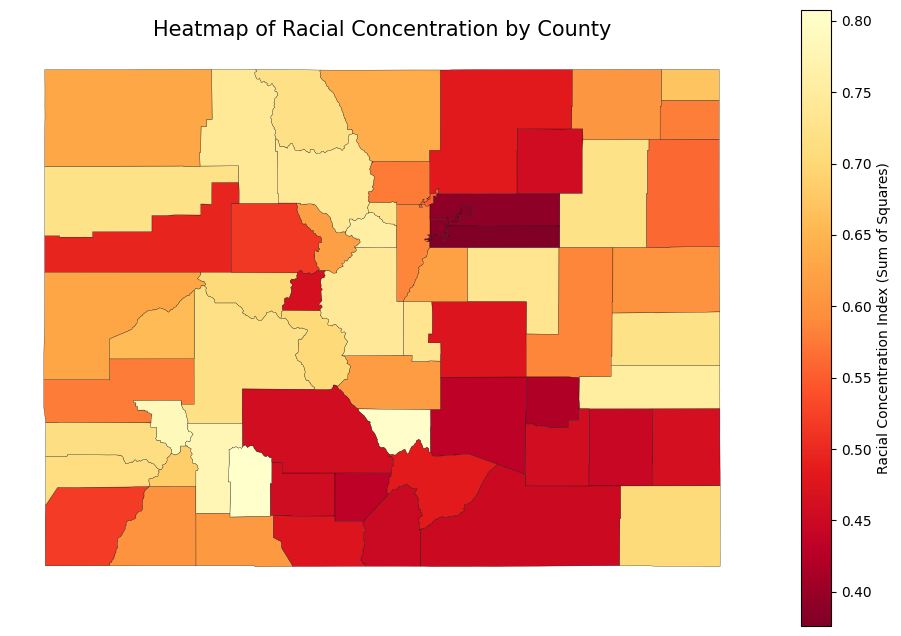

In [19]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

state_map.plot(column='diversity_index', 
               cmap='YlOrRd_r',  # Yellow to Orange to Red (Red = More Concentrated)
               legend=True,
               legend_kwds={'label': "Racial Concentration Index (Sum of Squares)"},
               ax=ax,
               edgecolor='black',
               linewidth=0.2)

ax.set_title('Heatmap of Racial Concentration by County', fontsize=15)
ax.axis('off')

plt.show()

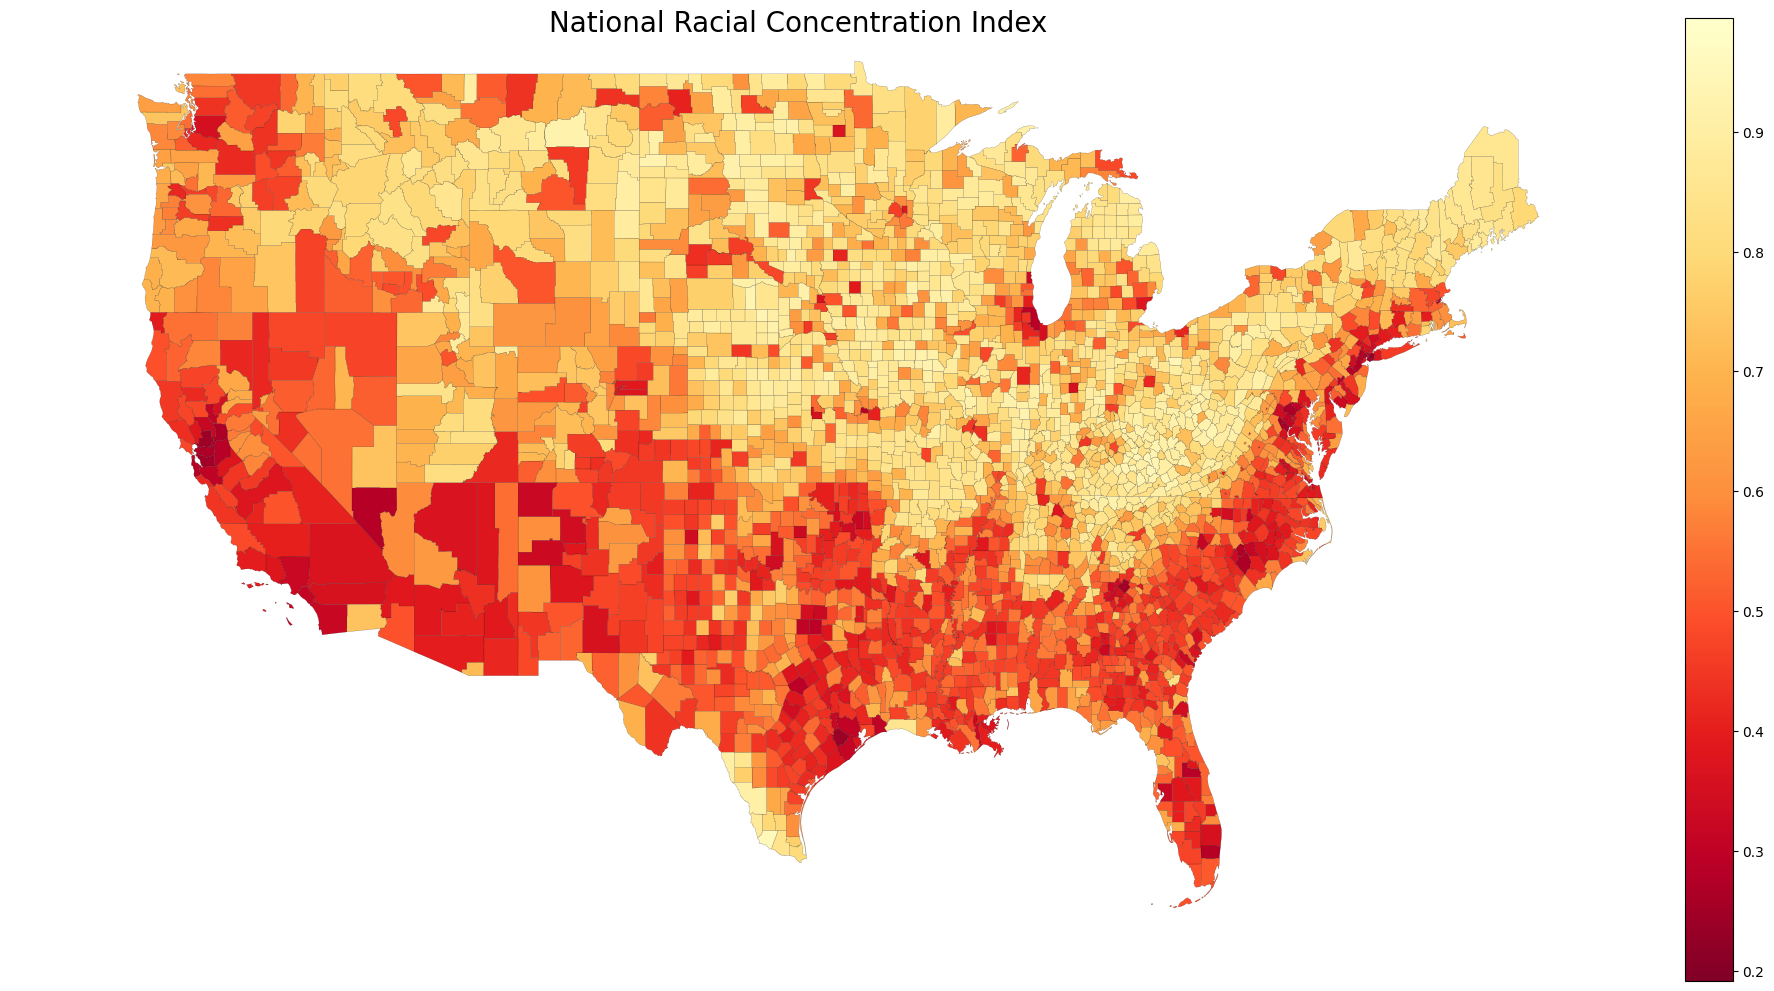

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the map
merged_map.plot(column='diversity_index', 
               cmap='YlOrRd_r', 
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.1)

# ZOOM into the contiguous United States
ax.set_xlim([-130, -65]) # Longitude
ax.set_ylim([23, 50])    # Latitude

ax.set_title('National Racial Concentration Index', fontsize=20)
ax.axis('off')

plt.tight_layout()
plt.show()

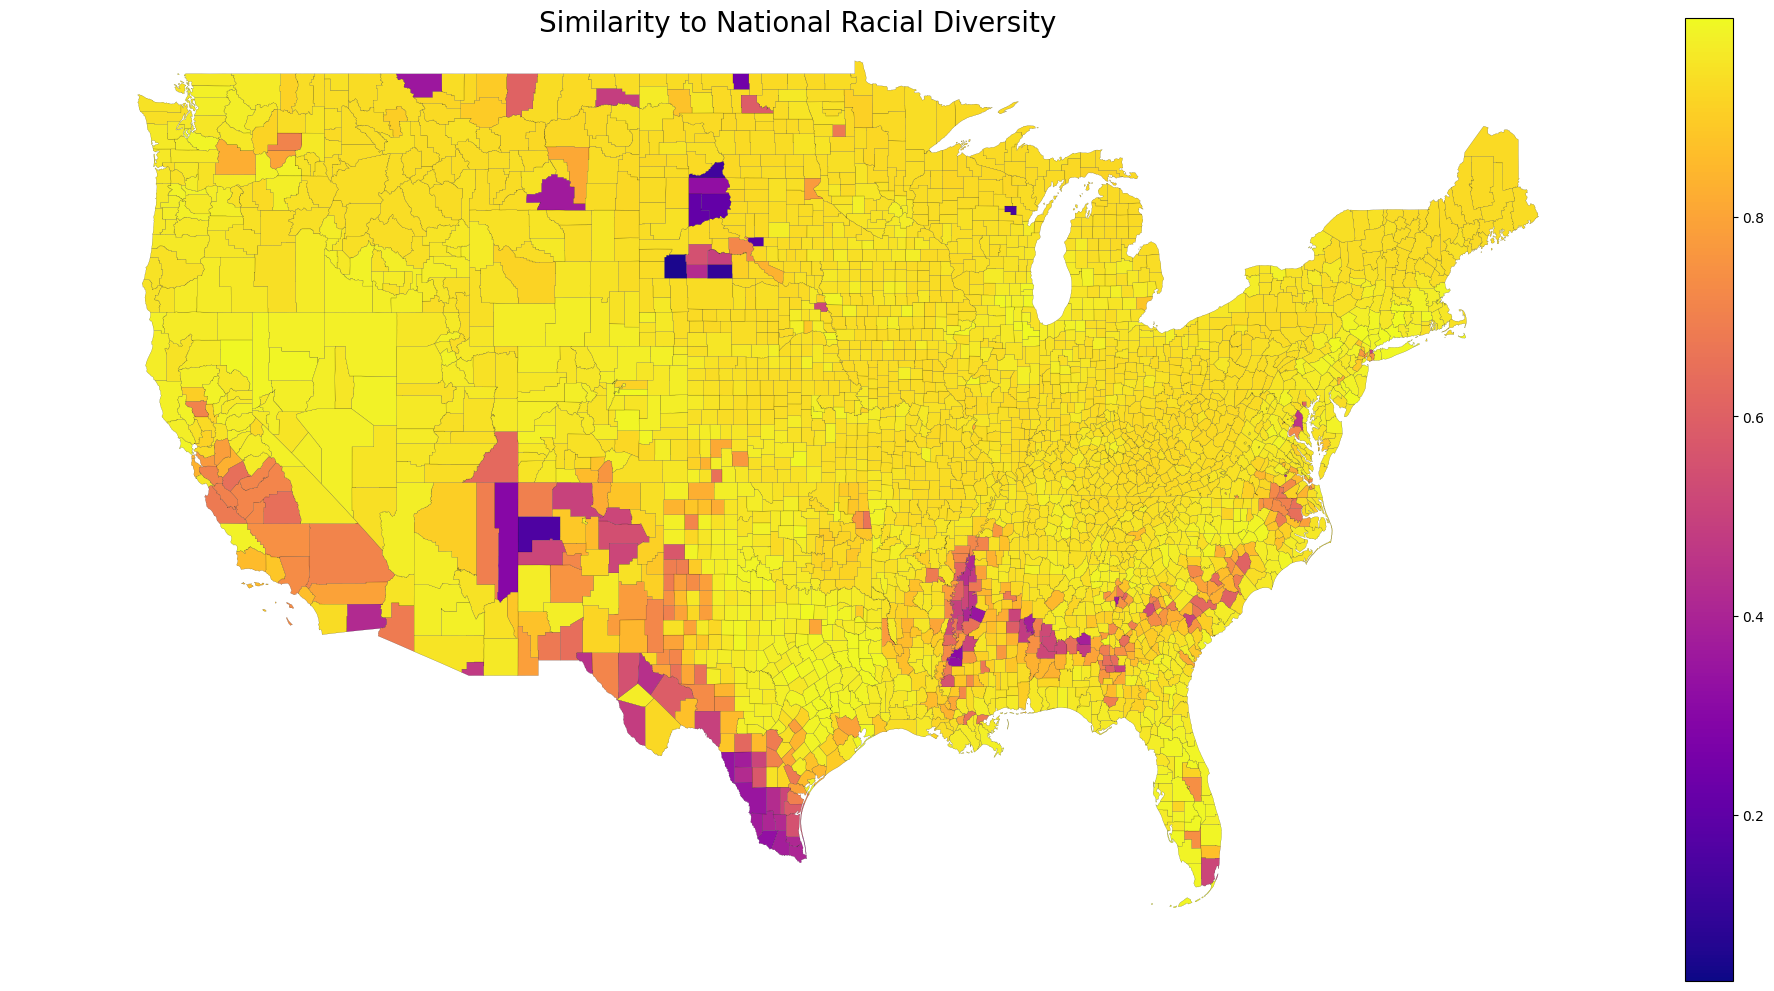

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the map
merged_map.plot(column='similarity_to_national', 
               cmap='plasma', 
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.1)

# ZOOM into the contiguous United States
ax.set_xlim([-130, -65]) # Longitude
ax.set_ylim([23, 50])    # Latitude

ax.set_title('Similarity to National Racial Diversity', fontsize=20)
ax.axis('off')

plt.tight_layout()
plt.show()

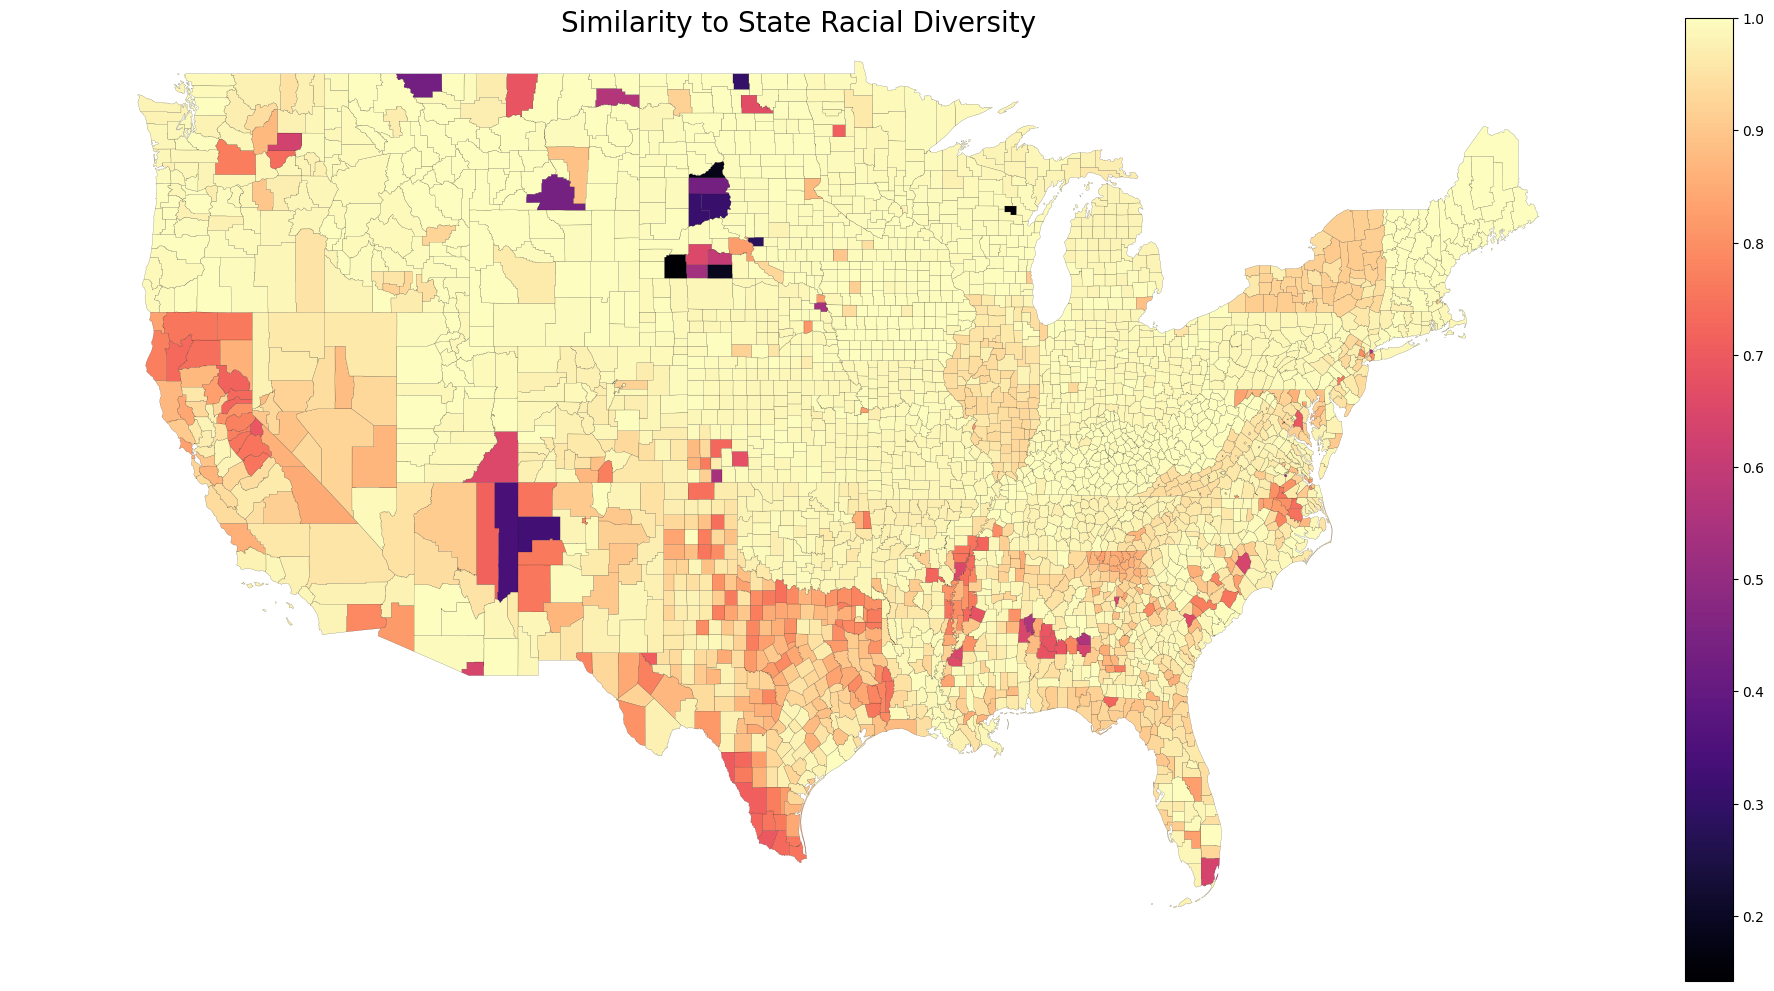

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the map
merged_map.plot(column='similarity_to_state', 
               cmap='magma', 
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.1)

# ZOOM into the contiguous United States
ax.set_xlim([-130, -65]) # Longitude
ax.set_ylim([23, 50])    # Latitude

ax.set_title('Similarity to State Racial Diversity', fontsize=20)
ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
merged_map

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,...,AWATER,geometry,GEO_ID,County_Name,race_proportion_vector,diversity_index,State_FIPS,similarity_to_national,similarity_to_state,FIPS
0,01,059,00161555,0500000US01059,01059,Franklin,Franklin County,AL,Alabama,06,...,32639621,"POLYGON ((-88.16591 34.38093, -88.16563 34.383...",0500000US01059,"Franklin County, Alabama","[0.1949, 0.7343, 0.0355, 0.004, 0.0021, 0.0001...",0.5792,01,0.9821,0.9289,01059
1,06,057,01682927,0500000US06057,06057,Nevada,Nevada County,CA,California,06,...,41531993,"POLYGON ((-121.27953 39.23054, -121.25918 39.2...",0500000US06057,"Nevada County, California","[0.1019, 0.8099, 0.0041, 0.0068, 0.0134, 0.001...",0.6698,06,0.9592,0.7230,06057
2,26,031,01622958,0500000US26031,26031,Cheboygan,Cheboygan County,MI,Michigan,06,...,440607445,"POLYGON ((-84.73269 45.28938, -84.73239 45.787...",0500000US26031,"Cheboygan County, Michigan","[0.0133, 0.8942, 0.0035, 0.0269, 0.0033, 0.0, ...",0.8037,26,0.9303,0.9810,26031
3,29,119,00758518,0500000US29119,29119,McDonald,McDonald County,MO,Missouri,06,...,520251,"POLYGON ((-94.61831 36.76656, -94.0689 36.7478...",0500000US29119,"McDonald County, Missouri","[0.1209, 0.7152, 0.0181, 0.0212, 0.0161, 0.037...",0.5331,29,0.9690,0.9855,29119
4,31,157,00835900,0500000US31157,31157,Scotts Bluff,Scotts Bluff County,NE,Nebraska,06,...,15402683,"POLYGON ((-104.05293 41.90614, -104.05299 41.9...",0500000US31157,"Scotts Bluff County, Nebraska","[0.2273, 0.7125, 0.0065, 0.0129, 0.0077, 0.000...",0.5605,31,0.9788,0.9867,31157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,13,301,00347777,0500000US13301,13301,Warren,Warren County,GA,Georgia,06,...,6034478,"POLYGON ((-82.8666 33.4666, -82.82314 33.50408...",0500000US13301,"Warren County, Georgia","[0.0102, 0.3785, 0.5843, 0.0035, 0.0029, 0.000...",0.4851,13,0.6693,0.8875,13301
3217,06,023,01681908,0500000US06023,06023,Humboldt,Humboldt County,CA,California,06,...,1253726036,"POLYGON ((-124.4086 40.4432, -124.39664 40.462...",0500000US06023,"Humboldt County, California","[0.1358, 0.6838, 0.0127, 0.0546, 0.0256, 0.003...",0.4957,06,0.9714,0.7706,06023
3218,34,023,00882230,0500000US34023,34023,Middlesex,Middlesex County,NJ,New Jersey,06,...,35291196,"POLYGON ((-74.6306 40.3396, -74.62024 40.37375...",0500000US34023,"Middlesex County, New Jersey","[0.2244, 0.386, 0.0912, 0.0014, 0.2641, 0.0002...",0.2781,34,0.8927,0.9321,34023
3219,13,311,00326781,0500000US13311,13311,White,White County,GA,Georgia,06,...,3917258,"POLYGON ((-83.8712 34.6649, -83.87251 34.68309...",0500000US13311,"White County, Georgia","[0.0326, 0.8913, 0.0167, 0.0037, 0.0057, 0.0, ...",0.7979,13,0.9395,0.8538,13311


In [23]:
# Store the merged data to manipulate with the school data later
merged_map.to_csv('../data/racial_comp_county.csv', index=False)